In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import R  # Ideal gas constant in J/(mol·K)
import pandas as pd
import re

# Load the CSV file into a DataFrame
df = pd.read_csv("ammonia_synthesis_data_rossetti_et_al.csv")

# Function to extract columns and molar flow per volume reactor
def extract_columns_and_molar_flow(df):
    """
    Extract columns starting with 'GHSV_' and calculate molar flow per volume reactor in SI units.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the columns with GHSV values.

    Returns:
    --------
    list of tuples
        List of (column_name, molar_flow_per_volume) pairs in SI units.
    """
    # Define standard temperature and pressure
    standard_temperature = 273.15  # Kelvin (0°C)
    standard_pressure = 101325  # Pascals (1 atm)

    columns_and_molar_flow = []
    for col in df.columns:
        match = re.match(r"GHSV_(\d+)", col)
        if match:
            gHSV = float(match.group(1))  # GHSV in 1/h
            # Convert GHSV to molar flow per volume reactor in SI units (mol/m³/s)
            molar_flow_per_volume = gHSV / 3600 * (standard_pressure / (R * standard_temperature))
            columns_and_molar_flow.append((col, molar_flow_per_volume))
    return columns_and_molar_flow

# Extract columns and molar flow per volume reactor
columns_and_molar_flow = extract_columns_and_molar_flow(df)

# Display the first few rows
print(df.head())


   Test  Pressure (bar)  Temperature (°C)  H2/N2 Ratio  GHSV_50000  \
0     1             100               430          1.5       13.20   
1     2             100               370          1.5        3.55   
2     3              85               370          1.5        3.41   
3     4              85               430          1.5       11.82   
4     7              70               370          3.0        2.19   

   GHSV_60000  GHSV_90000  GHSV_120000  GHSV_200000  GHSV_300000 GHSV_400000  \
0       12.62       11.66        10.05         7.62         4.87        3.60   
1        3.32        2.62         2.24         1.48         0.89        0.60   
2        3.08        2.43         2.00         1.43          NaN               
3       11.33        9.53         8.25         5.46         4.17        3.30   
4        1.91        1.43         1.14         0.60          NaN               

   TAve (°C)  Exp/Equ  
0      431.1     0.80  
1      366.9     0.17  
2      366.9     0.16  
3 

In [18]:
from ammonia_synthesis_kinetics import AmmoniaSynthesisKinetics
from scipy.integrate import solve_ivp

#rho_c = 590.0
#Dcat = 1.0 / 3.0
#eps = 0.4
#rho_b = rho_c * Dcat * (1 - eps)

species = ['N2', 'H2', 'NH3']
kinetics = AmmoniaSynthesisKinetics(species, rho_b=1.0, rho_c=1.0)

def ode_plugflow(F, p, kinetics):
    mol_frac = F / np.sum(F)  # Convert flow rates to mole fractions
    p_partial = mol_frac * p  # Convert mole fractions to partial pressures
    return kinetics(p_partial)  # Convert back to mol/m³/s



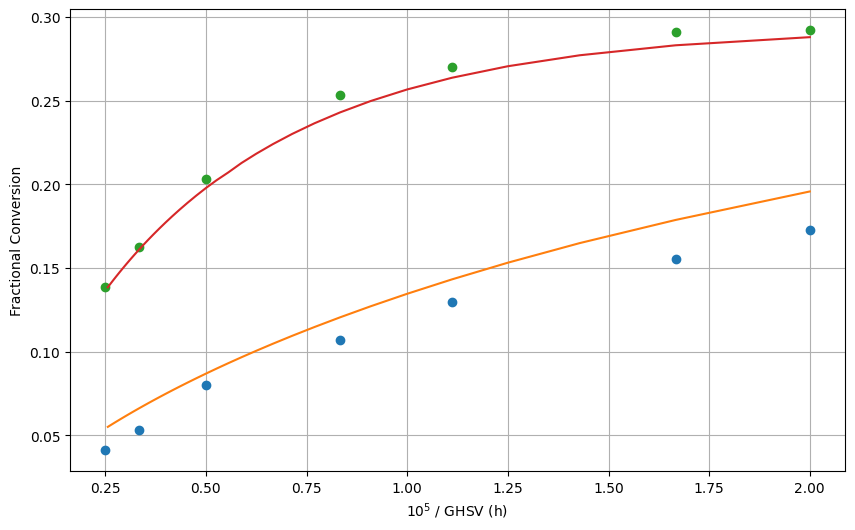

In [25]:

plt.figure(figsize=(10, 6))
standard_temperature = 273.15  # Kelvin (0°C)
standard_pressure = 101325  # Pascals (1 atm)
tests = [11, 22]
for test in tests:
    row = df[df["Test"] == test].iloc[0]
    gHSV = []
    conversion = []

    q = float(row['H2/N2 Ratio'])  # Ratio of H2 to N2
    for col, _ in columns_and_molar_flow:
        match = re.match(r"GHSV_(\d+)", col)
        if match:
            gHSV.append(float(match.group(1)))
            frac_NH3 = 1e-2*float(row[col])  # Fraction of NH3
            eta = 3.0 * (1.0 + 1.0 / q) * frac_NH3 / (2.0 * (1 + frac_NH3))  # Conversion of H2
            conversion.append(eta)
    # Plot the conversion against GHSV
    plt.plot(1e5 / np.array(gHSV), conversion, 'o')

    p = 1e5*row['Pressure (bar)']
    kinetics.set_T_and_p(273.15+row['Temperature (°C)'], p)  # Set temperature and pressure for kinetics
    conversion = []
    gHSV = np.arange(50000, 400000, 10000)  # GHSV values for interpolation
    composition = np.array([1.0 / (1.0 + q), q / (1.0 + q), 0.0])  # N2, H2, NH3 composition
    for gHSV_value in gHSV:
        F0 = gHSV_value/3600 * (standard_pressure/(R*standard_temperature))*composition  # Initial flow rates
        sol = solve_ivp(lambda zeta, F: ode_plugflow(F, p, kinetics), [0, 1], F0, t_eval=[1])
        conversion.append((F0[1] - sol.y[1, 0])/F0[1])
    plt.plot(1e5 / np.array(gHSV), conversion, '-')
    
plt.xlabel(r"$10^5$ / GHSV (h)")
plt.ylabel("Fractional Conversion")
plt.grid()
plt.show()


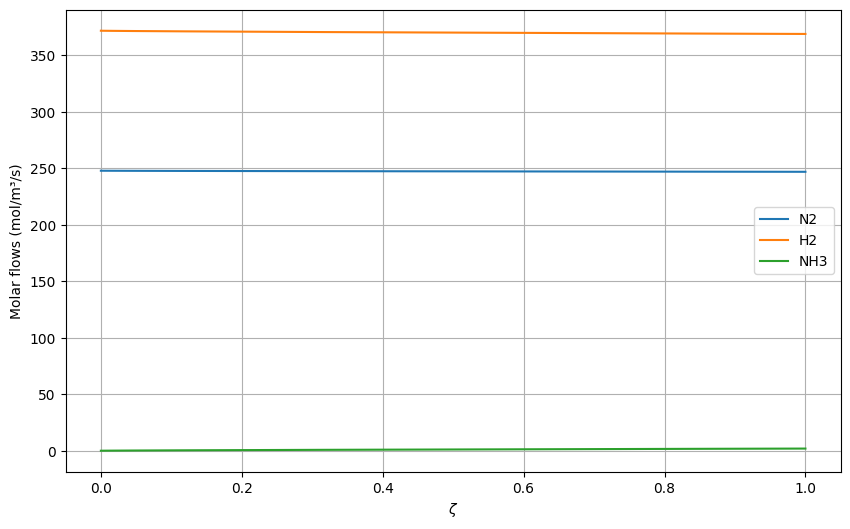

In [ ]:

p = df['Pressure (bar)'][0] * 1e5  # Convert pressure from bar to Pa
ratio= df['H2/N2 Ratio'][0]  # Ratio of H2 to N2
composition = np.array([1.0 / (1.0 + ratio), ratio / (1.0 + ratio), 0.0])  # N2, H2, NH3 composition
F0 = composition * columns_and_molar_flow[0][1]
zeta_span = (0, 1)  # Spatial dimensionless domain for plug flow reactor
result = solve_ivp(lambda t, F: ode_plugflow(F, p, T, kinetics), zeta_span, F0)

# Plot the results
plt.figure(figsize=(10, 6))
for i, species_name in enumerate(species):
    plt.plot(result.t, result.y[i], label=species_name)
plt.xlabel(r"$\zeta$")
plt.ylabel("Molar flows (mol/m³/s)")
plt.legend()
plt.grid()
plt.show()


In [14]:
from scipy.constants import calorie
Rc = R / calorie
#print(56.9024 / R)
#print(9000 / (calorie))
# KH2=np.exp(-56.9024/Ra+37656/(Ra*T))
#adsorption equilibrium constant for NH3
# KNH3=np.exp(-34.7272/Ra+29228/(Ra*T))


print(9000 / Rc)
print(37656/ R)  # Convert calorie to J/(mol·K)

4528.975801488892
4528.975801488892
